In [1]:

import os
import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import glob
warnings.filterwarnings('ignore')

# TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Conv2DTranspose

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Semillas
np.random.seed(42)
tf.random.set_seed(42)

## Constantes


In [2]:
# Parámetros
CODIGO = "20251595004"
PROCESSED_PATH = "processed"
RAW_PATH = "raw"
IMG_SIZE = (233, 233)
IMG_CHANNELS = 3
LATENT_DIM = 64  # Dimensión del espacio latente

# Mapeo de objetos
OBJETOS = ['cpu', 'mesa', 'mouse', 'pantalla', 'nada', 'silla', 'teclado']
NUM_CLASSES = len(OBJETOS)

print(f"Configuración:")
print(f"   - Código estudiante: {CODIGO}")
print(f"   - Dimensiones imagen: {IMG_SIZE} x {IMG_CHANNELS}")
print(f"   - Dimensión latente: {LATENT_DIM}")
print(f"   - Clases: {NUM_CLASSES} → {OBJETOS}")

Configuración:
   - Código estudiante: 20251595004
   - Dimensiones imagen: (233, 233) x 3
   - Dimensión latente: 64
   - Clases: 7 → ['cpu', 'mesa', 'mouse', 'pantalla', 'nada', 'silla', 'teclado']


## Extracción de frames

In [3]:
def extract_frames_from_video(video_path, output_dir, codigo, objeto, target_size=(233, 233), max_frames=20):
    """
    Procesa un archivo de video para obtener imágenes individuales con dimensiones específicas
    manteniendo las proporciones originales
    
    Args:
        video_path: Ubicación del archivo de video
        output_dir: Carpeta destino para las imágenes
        codigo: Identificador del estudiante
        objeto: Categoría del objeto (cpu, mesa, mouse, etc.)
        target_size: Resolución final deseada (ancho, alto)
        max_frames: Cantidad máxima de imágenes a obtener
    """
    
    # Verificar y generar carpeta de destino
    os.makedirs(output_dir, exist_ok=True)
    
    # Inicializar captura de video
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: No se pudo abrir el video {video_path}")
        return
    
    # Extraer propiedades del archivo de video
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps if fps > 0 else 0
    
    print(f"Procesando {video_path}")
    print(f"  - FPS: {fps:.2f}")
    print(f"  - Total frames: {total_frames}")
    print(f"  - Duración: {duration:.2f} segundos")
    
    # Determinar frecuencia de muestreo de frames
    if total_frames <= max_frames:
        frame_interval = 1  # Usar todos los frames disponibles
        max_frames = total_frames
    else:
        frame_interval = total_frames // max_frames  # Seleccionar frames de manera uniforme
    
    print(f"  - Extrayendo exactamente {max_frames} frames (intervalo: {frame_interval})")
    
    frame_count = 0
    extracted_count = 0
    
    while True:
        ret, frame = cap.read()
        
        if not ret or extracted_count >= max_frames:
            break
            
        # Procesar únicamente frames en el intervalo especificado
        if frame_count % frame_interval == 0:
            # Determinar dimensiones actuales del frame
            h, w = frame.shape[:2]
            target_w, target_h = target_size
            
            # Establecer factor de redimensionamiento preservando proporciones
            scale_w = target_w / w
            scale_h = target_h / h
            scale = max(scale_w, scale_h)  # Factor que cubre completamente el área objetivo
            
            # Aplicar redimensionamiento proporcional
            new_w = int(w * scale)
            new_h = int(h * scale)
            resized_frame = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)
            
            # Definir coordenadas para recorte centrado
            start_x = (new_w - target_w) // 2
            start_y = (new_h - target_h) // 2
            end_x = start_x + target_w
            end_y = start_y + target_h
            
            # Validar límites de coordenadas
            start_x = max(0, start_x)
            start_y = max(0, start_y)
            end_x = min(new_w, end_x)
            end_y = min(new_h, end_y)
            
            # Aplicar recorte centrado
            cropped_frame = resized_frame[start_y:end_y, start_x:end_x]
            
            # Ajustar dimensiones finales si es necesario
            if cropped_frame.shape[:2] != (target_h, target_w):
                cropped_frame = cv2.resize(cropped_frame, target_size, interpolation=cv2.INTER_AREA)
            
            # Construir nombre único para el archivo
            frame_filename = f"{codigo}_{objeto}_{extracted_count+1:04d}.png"
            frame_path = os.path.join(output_dir, frame_filename)
            
            # Almacenar frame procesado
            cv2.imwrite(frame_path, cropped_frame, [cv2.IMWRITE_PNG_COMPRESSION, 6])
            
            extracted_count += 1
            print(f"  - Frame {extracted_count} extraído: {frame_filename}")
        
        frame_count += 1
    
    cap.release()
    print(f"  - Total frames extraídos: {extracted_count}\n")
    return extracted_count

In [4]:
video_mapping = {
    "cpu": "cpu",
    "mesa": "mesa", 
    "mouse": "mouse",
    "pantalla": "pantalla",
    "ruido": "nada",  
    "silla": "silla",
    "teclado": "teclado"
}

total_extracted = 0

print(f"Dimensiones objetivo: 233x233x3")
print(f"Método: Crop centrado (mantiene relación de aspecto)")
print(f"Directorio de videos: {RAW_PATH}")
print(f"Directorio de salida: {PROCESSED_PATH}")
print("=" * 60)

# Iterar sobre cada archivo de video disponible
for video_name, folder_name in video_mapping.items():
    video_file = f"{CODIGO}_{video_name}.mp4"
    video_path = os.path.join(RAW_PATH, video_file)
    output_dir = os.path.join(PROCESSED_PATH, folder_name)

    if os.path.exists(video_path):
        extracted = extract_frames_from_video(
            video_path, output_dir, CODIGO, folder_name, target_size=(233, 233)
        )
        total_extracted += extracted
    else:
        print(f"⚠️   Video no encontrado: {video_path}")

print("=" * 60)
print(f" PROCESO COMPLETADO")
print(f"Total de frames extraídos: {total_extracted}")
print(f"Videos procesados: {len(video_mapping)}")

# Revisar contenido de las carpetas generadas
print("\n RESUMEN POR CATEGORÍA:")
for folder_name in video_mapping.values():
    folder_path = os.path.join(PROCESSED_PATH, folder_name)
    if os.path.exists(folder_path):
        alvaro_files = [f for f in os.listdir(folder_path) if f.startswith(CODIGO)]
        print(f"  - {folder_name}: {len(alvaro_files)} frames")

Dimensiones objetivo: 233x233x3
Método: Crop centrado (mantiene relación de aspecto)
Directorio de videos: raw
Directorio de salida: processed
Procesando raw\20251595004_cpu.mp4
  - FPS: 30.00
  - Total frames: 109
  - Duración: 3.63 segundos
  - Extrayendo exactamente 20 frames (intervalo: 5)
  - Frame 1 extraído: 20251595004_cpu_0001.png
  - Frame 2 extraído: 20251595004_cpu_0002.png
  - Frame 3 extraído: 20251595004_cpu_0003.png
  - Frame 4 extraído: 20251595004_cpu_0004.png
  - Frame 5 extraído: 20251595004_cpu_0005.png
  - Frame 6 extraído: 20251595004_cpu_0006.png
  - Frame 7 extraído: 20251595004_cpu_0007.png
  - Frame 8 extraído: 20251595004_cpu_0008.png
  - Frame 9 extraído: 20251595004_cpu_0009.png
  - Frame 10 extraído: 20251595004_cpu_0010.png
  - Frame 11 extraído: 20251595004_cpu_0011.png
  - Frame 12 extraído: 20251595004_cpu_0012.png
  - Frame 13 extraído: 20251595004_cpu_0013.png
  - Frame 14 extraído: 20251595004_cpu_0014.png
  - Frame 15 extraído: 20251595004_cpu_001

##  Carga y Exploración de Datos

In [5]:
def cargar_datos(PROCESSED_PATH, objetos, img_size):
    """
    Importa el conjunto completo de imágenes desde las carpetas organizadas
    Aplica redimensionamiento con relleno blanco para mantener proporciones
    Compatible con múltiples formatos de imagen
    """
    imagenes = []
    etiquetas = []
    rutas_archivos = []
    archivos_procesados = 0
    archivos_corregidos = 0
    
    def resize_con_padding(imagen, target_size):
        """
        Ajusta el tamaño preservando la relación de aspecto y agregando relleno blanco
        Evita el recorte para conservar toda la información visual
        """
        h, w = imagen.shape[:2]
        target_w, target_h = target_size
        
        # Determinar factor de escalamiento para ajuste completo
        scale_w = target_w / w
        scale_h = target_h / h
        scale = min(scale_w, scale_h)  # Factor mínimo para encajar completamente
        
        # Realizar escalamiento manteniendo proporciones
        new_w = int(w * scale)
        new_h = int(h * scale)
        resized = cv2.resize(imagen, (new_w, new_h), interpolation=cv2.INTER_AREA)
        
        # Generar lienzo blanco con dimensiones objetivo
        resultado = np.ones((target_h, target_w, 3), dtype=imagen.dtype) * 255
        
        # Establecer posición para centrado de la imagen escalada
        start_x = (target_w - new_w) // 2
        start_y = (target_h - new_h) // 2
        end_x = start_x + new_w
        end_y = start_y + new_h
        
        # Insertar imagen escalada en el centro del lienzo
        resultado[start_y:end_y, start_x:end_x] = resized
        
        return resultado
    
    print(" Importando conjunto completo de imágenes...")
    print(f" Resolución objetivo: {img_size[0]}x{img_size[1]}x3")
    print(f" Formatos compatibles: PNG, JPG, JPEG")
    print(f" Técnica: Relleno blanco sin recorte")
    print("=" * 60)
    
    for idx, objeto in enumerate(objetos):
        objeto_dir = os.path.join(PROCESSED_PATH, objeto)
        if not os.path.exists(objeto_dir):
            print(f" Directorio no localizado: {objeto_dir}")
            continue
            
        # Localizar archivos de imagen compatibles
        archivos = [f for f in os.listdir(objeto_dir) 
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        print(f" {objeto}: {len(archivos)} imágenes localizadas")
        
        archivos_clase = 0
        corregidos_clase = 0
        formatos_encontrados = set()
        
        for archivo in archivos:
            ruta_completa = os.path.join(objeto_dir, archivo)
            
            # Identificar tipo de archivo
            extension = archivo.lower().split('.')[-1]
            formatos_encontrados.add(extension.upper())
            
            # Importar imagen desde archivo
            img = cv2.imread(ruta_completa)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Conversión de espacio de color
                original_shape = img.shape
                
                # Evaluar necesidad de ajuste dimensional
                necesita_correccion = (img.shape[0] != img_size[1] or 
                                     img.shape[1] != img_size[0] or 
                                     img.shape[2] != 3)
                
                if necesita_correccion:
                    img = resize_con_padding(img, img_size)
                    corregidos_clase += 1
                    archivos_corregidos += 1
                    if corregidos_clase <= 3:  # Reportar primeros casos
                        print(f"    {archivo}: {original_shape} → {img.shape} (con relleno)")
                
                # Aplicar normalización a rango [0,1]
                img = img.astype(np.float32) / 255.0
                
                imagenes.append(img)
                etiquetas.append(idx)
                rutas_archivos.append(ruta_completa)
                archivos_clase += 1
                archivos_procesados += 1
            else:
                print(f"   Fallo al cargar: {archivo}")
        
        if corregidos_clase > 3:
            print(f"    ... y {corregidos_clase - 3} imágenes adicionales con relleno")
        
        # Reportar tipos de archivo procesados
        if formatos_encontrados:
            formatos_str = ", ".join(sorted(formatos_encontrados))
            print(f"    Tipos de archivo: {formatos_str}")
        
        print(f"    {archivos_clase} imágenes procesadas exitosamente")
    
    print("=" * 60)
    print(f" RESUMEN DE PROCESAMIENTO:")
    print(f"   - Total de imágenes procesadas: {archivos_procesados}")
    print(f"   - Imágenes con relleno aplicado: {archivos_corregidos}")
    print(f"   - Imágenes sin modificación: {archivos_procesados - archivos_corregidos}")
    
    # Reportar formatos globales procesados
    all_extensions = set([os.path.splitext(r)[1].lower() for r in rutas_archivos])
    all_formats = [ext.replace('.', '').upper() for ext in all_extensions]
    print(f"   - Formatos procesados: {', '.join(sorted(all_formats))}")
    print(f"   - Información visual preservada completamente")
    
    return np.array(imagenes), np.array(etiquetas), rutas_archivos

# Inicializar proceso de carga del dataset completo
print(" Comenzando importación del dataset...")
X, y, rutas = cargar_datos(PROCESSED_PATH, OBJETOS, IMG_SIZE)

print(f"\n DATASET RESULTANTE:")
print(f"   - Estructura de X: {X.shape}")
print(f"   - Estructura de y: {y.shape}")
print(f"   - Rango de valores en X: [{X.min():.3f}, {X.max():.3f}]")
print(f"   - Rango de valores en Y: [{y.min()}, {y.max()}]")
print(f"   - Categorías presentes: {np.unique(y)}")
print(f"   - Estudiantes en el dataset: {len(set([os.path.basename(r).split('_')[0] for r in rutas]))}")

# Validar consistencia dimensional
print(f"\n VALIDACIÓN DE DIMENSIONES:")
shapes_unicas = set([img.shape for img in X])
print(f"   - Estructuras únicas encontradas: {shapes_unicas}")
if len(shapes_unicas) == 1:
    print("   - Dimensiones uniformes en todo el dataset")
else:
    print("   - Se detectaron inconsistencias dimensionales")

# Inspeccionar aplicación de relleno blanco
print(f"\n INSPECCIÓN DE RELLENO:")
sample_img = X[0]
corners = [
    sample_img[0, 0],      # esquina superior izquierda
    sample_img[0, -1],     # esquina superior derecha  
    sample_img[-1, 0],     # esquina inferior izquierda
    sample_img[-1, -1]     # esquina inferior derecha
]
corner_values = [np.mean(corner) for corner in corners]
print(f"   - Intensidad promedio en esquinas: {corner_values}")
if all(val > 0.9 for val in corner_values):
    print("   - Relleno blanco aplicado correctamente")
else:
    print("   - Las esquinas no presentan relleno (imagen completa)")

 Comenzando importación del dataset...
 Importando conjunto completo de imágenes...
 Resolución objetivo: 233x233x3
 Formatos compatibles: PNG, JPG, JPEG
 Técnica: Relleno blanco sin recorte
 cpu: 182 imágenes localizadas
    20172167090_Cpu_1.png: (850, 478, 3) → (233, 233, 3) (con relleno)
    20172167090_Cpu_10.png: (850, 478, 3) → (233, 233, 3) (con relleno)
    20172167090_Cpu_2.png: (850, 478, 3) → (233, 233, 3) (con relleno)
    ... y 139 imágenes adicionales con relleno
    Tipos de archivo: JPG, PNG
    182 imágenes procesadas exitosamente
 mesa: 253 imágenes localizadas
    20172167090_Mesa_1.png: (478, 848, 3) → (233, 233, 3) (con relleno)
    20172167090_Mesa_10.png: (478, 848, 3) → (233, 233, 3) (con relleno)
    20172167090_Mesa_2.png: (478, 848, 3) → (233, 233, 3) (con relleno)
    ... y 210 imágenes adicionales con relleno
    Tipos de archivo: JPG, PNG
    253 imágenes procesadas exitosamente
 mouse: 238 imágenes localizadas
    20172167090_Mouse_1.png: (478, 848, 3) →

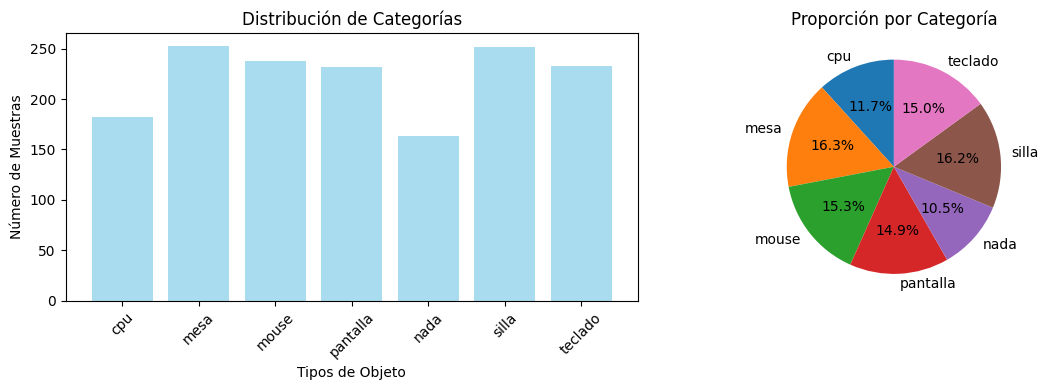

Análisis estadístico por categoría:
          cpu: 182 muestras ( 11.7%)
         mesa: 253 muestras ( 16.3%)
        mouse: 238 muestras ( 15.3%)
     pantalla: 232 muestras ( 14.9%)
         nada: 163 muestras ( 10.5%)
        silla: 252 muestras ( 16.2%)
      teclado: 233 muestras ( 15.0%)


In [6]:
# Generar visualización de la distribución por categorías
plt.figure(figsize=(12, 4))

# Gráfico 1: Conteo absoluto por categoría
plt.subplot(1, 2, 1)
class_counts = np.bincount(y)
plt.bar(OBJETOS, class_counts, color='skyblue', alpha=0.7)
plt.title('Distribución de Categorías')
plt.xlabel('Tipos de Objeto')
plt.ylabel('Número de Muestras')
plt.xticks(rotation=45)

# Gráfico 2: Representación porcentual
plt.subplot(1, 2, 2)
percentages = class_counts / len(y) * 100
plt.pie(percentages, labels=OBJETOS, autopct='%1.1f%%', startangle=90)
plt.title('Proporción por Categoría')

plt.tight_layout()
plt.show()

# Generar reporte estadístico detallado
print("Análisis estadístico por categoría:")
for i, objeto in enumerate(OBJETOS):
    count = class_counts[i]
    pct = percentages[i]
    print(f"   {objeto:>10}: {count:>2} muestras ({pct:>5.1f}%)")

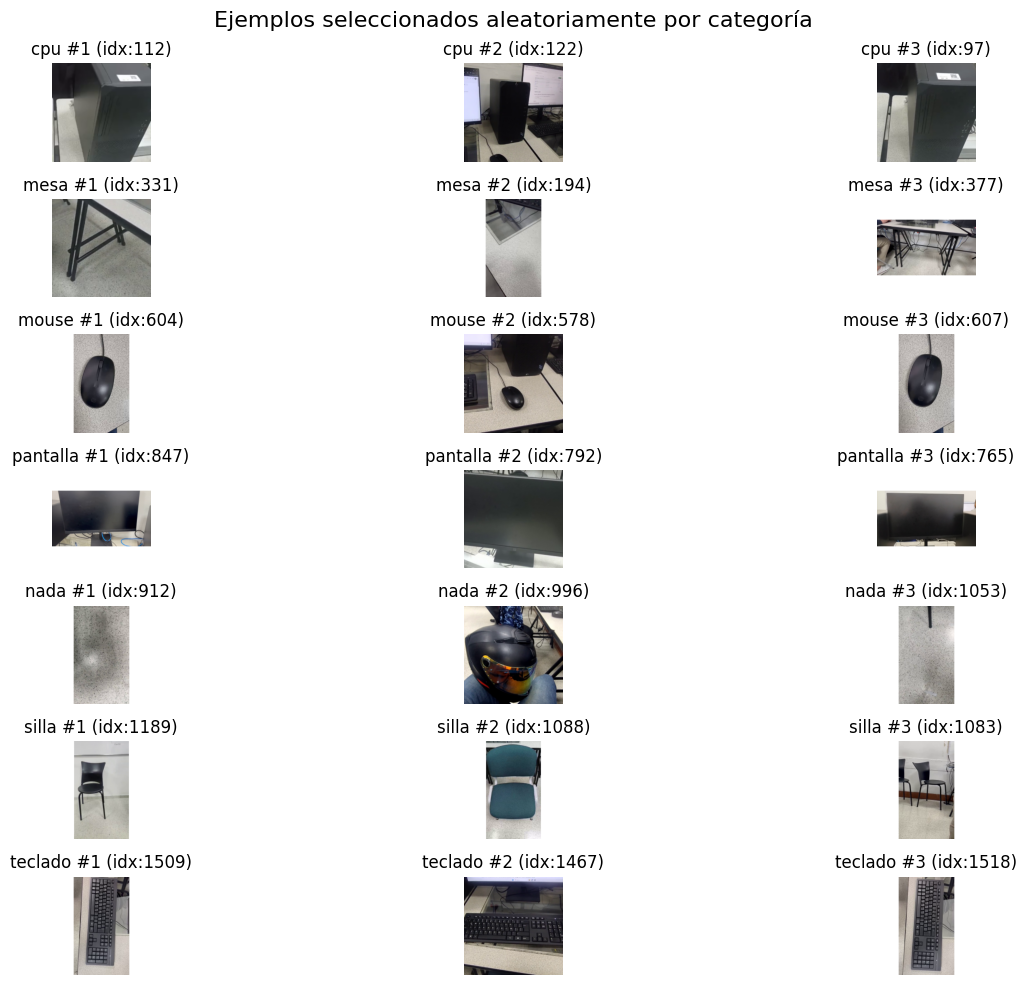

In [7]:
# Mostrar ejemplos seleccionados aleatoriamente de cada categoría
plt.figure(figsize=(15, 10))

# Establecer semilla para reproducibilidad
np.random.seed(None)  # Usar None para variabilidad en cada ejecución

for i, objeto in enumerate(OBJETOS):
    # Localizar muestras de la categoría actual
    indices_clase = np.where(y == i)[0]
    
    if len(indices_clase) > 0:
        # Elegir hasta 3 muestras al azar por categoría
        num_ejemplos = min(3, len(indices_clase))
        indices_aleatorios = np.random.choice(indices_clase, size=num_ejemplos, replace=False)
        
        for j in range(num_ejemplos):
            plt.subplot(len(OBJETOS), 3, i * 3 + j + 1)
            
            idx = indices_aleatorios[j]
            img = X[idx]
            
            plt.imshow(img)
            plt.title(f'{objeto} #{j+1} (idx:{idx})')
            plt.axis('off')
    else:
        # Caso de categoría sin muestras disponibles
        plt.subplot(len(OBJETOS), 3, i * 3 + 1)
        plt.text(0.5, 0.5, f'Sin\nmuestras de\n{objeto}', 
                ha='center', va='center', fontsize=12)
        plt.axis('off')

plt.suptitle('Ejemplos seleccionados aleatoriamente por categoría', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

##  Construcción del Autoencoder

In [8]:
class Autoencoder(keras.Model):
    def __init__(self, latent_dim, shape):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.shape = shape
        
        # Construcción del codificador (encoder)
        self.encoder = keras.Sequential([
            layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=shape),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.MaxPooling2D((2, 2), padding='same'),
            layers.Flatten(),
            layers.Dense(latent_dim, activation='relu', name='latent_space')
        ], name='encoder')
        
        # Cálculo de dimensiones tras las operaciones convolucionales
        # Transformación 233x233 con padding='same': 233 -> 117 -> 59 (mediante MaxPooling2D)
        import math
        conv_output_h = math.ceil(math.ceil(shape[0] / 2) / 2)  # 233 -> 117 -> 59
        conv_output_w = math.ceil(math.ceil(shape[1] / 2) / 2)  # 233 -> 117 -> 59
        conv_output_channels = 64
        
        # Construcción del decodificador (decoder) con capas avanzadas de reconstrucción
        self.decoder = keras.Sequential([
            layers.Dense(conv_output_h * conv_output_w * conv_output_channels, activation='relu'),
            layers.Reshape((conv_output_h, conv_output_w, conv_output_channels)),
            layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
            layers.UpSampling2D((2, 2)),
            layers.Conv2D(shape[2], (3, 3), activation='sigmoid', padding='same'),
            # Capa de ajuste dimensional para obtener resolución exacta
            layers.Lambda(lambda x: tf.image.resize(x, [shape[0], shape[1]], method='bilinear'))
        ], name='decoder')

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded
    
    def encode(self, x):
        """Función para obtener únicamente las características del codificador"""
        return self.encoder(x)

# Instanciar autoencoder con la arquitectura personalizada
input_shape = (IMG_SIZE[0], IMG_SIZE[1], IMG_CHANNELS)
autoencoder = Autoencoder(LATENT_DIM, input_shape)

# Configurar optimización del autoencoder
autoencoder.compile(
    optimizer='adam',
    loss='mse',  # Error cuadrático medio para reconstrucción
    metrics=['mae']  # Error absoluto medio
)

print("Autoencoder personalizado implementado")
print(f"Especificaciones:")
print(f"   - Dimensiones de entrada: {input_shape}")
print(f"   - Dimensionalidad del espacio latente: {LATENT_DIM}")
print(f"   - Compresión total: {tf.math.reduce_prod(input_shape).numpy()} -> {LATENT_DIM}")

# Inicializar arquitectura mediante ejemplo de datos
sample_data = tf.random.normal((1,) + input_shape)
_ = autoencoder(sample_data)

print(f"   - Parámetros del codificador: {autoencoder.encoder.count_params()}")
print(f"   - Parámetros del decodificador: {autoencoder.decoder.count_params()}")

Autoencoder personalizado implementado
Especificaciones:
   - Dimensiones de entrada: (233, 233, 3)
   - Dimensionalidad del espacio latente: 64
   - Compresión total: 162867 -> 64

   - Parámetros del codificador: 14277632
   - Parámetros del decodificador: 14537219


In [9]:
# Inspeccionar estructura del autoencoder
print("Estructura del Codificador:")
autoencoder.encoder.summary()

print("\nEstructura del Decodificador:")
autoencoder.decoder.summary()

print("\nResumen del Autoencoder completo:")
print(f"Dimensiones de entrada: {input_shape}")
print(f"Dimensionalidad latente: {LATENT_DIM}")
print(f"Dimensiones de salida: {input_shape}")
print(f"Factor de compresión: {tf.math.reduce_prod(input_shape).numpy() / LATENT_DIM:.1f}x")

Estructura del Codificador:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 233, 233, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 117, 117, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 117, 117, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 59, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 222784)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 64)             │    14,258,240 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,277,632 (54.46 MB)

 Trainable params: 14,277,632 (54.46 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (1, 222784)            │    14,480,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (1, 59, 59, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 59, 59, 64)        │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (1, 118, 118, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 118, 118, 32)      │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (1, 236, 236, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (1, 236, 236, 3)       │           867 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (1, 233, 233, 3)       │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,537,219 (55.46 MB)

 Trainable params: 14,537,219 (55.46 MB)

 Non-trainable params: 0 (0.00 B)


Resumen del Autoencoder completo:
Dimensiones de entrada: (233, 233, 3)
Dimensionalidad latente: 64
Dimensiones de salida: (233, 233, 3)
Factor de compresión: 2544.8x


##  Entrenamiento del Autoencoder

In [10]:
# El autoencoder desarrolla capacidad de reconstrucción sobre todo el conjunto (sin supervisión)

# Realizar partición balanceada del dataset por categorías
X_train_ae, X_test_ae, y_train_ae, y_test_ae = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f" Partición de datos para autoencoder:")
print(f"   - Conjunto de entrenamiento: {X_train_ae.shape[0]} imágenes")
print(f"   - Conjunto de evaluación: {X_test_ae.shape[0]} imágenes")

# Inspeccionar balance de categorías
print(f"\nBalance de categorías en entrenamiento:")
train_counts = np.bincount(y_train_ae)
for i, objeto in enumerate(OBJETOS):
    print(f"   {objeto:>10}: {train_counts[i]} imágenes ({train_counts[i]/len(y_train_ae)*100:.1f}%)")

print(f"\nBalance de categorías en evaluación:")
test_counts = np.bincount(y_test_ae)
for i, objeto in enumerate(OBJETOS):
    print(f"   {objeto:>10}: {test_counts[i]} imágenes ({test_counts[i]/len(y_test_ae)*100:.1f}%)")

# Buscar modelo autoencoder preexistente
autoencoder_weights_path = f"models/{CODIGO}_autoencoder.weights.h5"

if os.path.exists(autoencoder_weights_path):
    print(f" Restaurando autoencoder desde: {autoencoder_weights_path}")
    autoencoder.load_weights(autoencoder_weights_path)
    print(" Autoencoder restaurado correctamente!")
    
    # Evaluar rendimiento del modelo restaurado
    test_loss, test_mae = autoencoder.evaluate(X_test_ae, X_test_ae, verbose=0)
    print(f" Métricas del autoencoder restaurado:")
    print(f"   - Pérdida MSE: {test_loss:.4f}")
    print(f"   - Error MAE: {test_mae:.4f}")
    
    # Generar historial simulado para compatibilidad
    history_ae = type('History', (), {
        'history': {
            'loss': [test_loss],
            'val_loss': [test_loss], 
            'mae': [test_mae],
            'val_mae': [test_mae]
        }
    })()
    
else:
    print(f" Modelo no encontrado en: {autoencoder_weights_path}")
    print(" Iniciando entrenamiento desde estado inicial...")
    
    # Configurar mecanismos de control de entrenamiento
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7
        )
    ]

    # Ejecutar proceso de entrenamiento del autoencoder
    print("\n Comenzando optimización del autoencoder...")
    history_ae = autoencoder.fit(
        X_train_ae, X_train_ae,  # Entrada = Salida (tarea de reconstrucción)
        validation_data=(X_test_ae, X_test_ae),
        epochs=50,
        batch_size=100,  
        callbacks=callbacks,
        verbose=1
    )

    print(" Entrenamiento del autoencoder completado!")
    
    # Persistir modelo entrenado
    os.makedirs("models", exist_ok=True)
    autoencoder.save_weights(autoencoder_weights_path)
    print(f" Autoencoder almacenado en: {autoencoder_weights_path}")

 Partición de datos para autoencoder:
   - Conjunto de entrenamiento: 1242 imágenes
   - Conjunto de evaluación: 311 imágenes

Balance de categorías en entrenamiento:
          cpu: 146 imágenes (11.8%)
         mesa: 202 imágenes (16.3%)
        mouse: 190 imágenes (15.3%)
     pantalla: 186 imágenes (15.0%)
         nada: 130 imágenes (10.5%)
        silla: 202 imágenes (16.3%)
      teclado: 186 imágenes (15.0%)

Balance de categorías en evaluación:
          cpu: 36 imágenes (11.6%)
         mesa: 51 imágenes (16.4%)
        mouse: 48 imágenes (15.4%)
     pantalla: 46 imágenes (14.8%)
         nada: 33 imágenes (10.6%)
        silla: 50 imágenes (16.1%)
      teclado: 47 imágenes (15.1%)
 Modelo no encontrado en: models/20251595004_autoencoder.weights.h5
 Iniciando entrenamiento desde estado inicial...

 Comenzando optimización del autoencoder...
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - loss: 0.0879 - mae: 0.2481 - val_loss: 0.0634 - val_mae: 0.2009 - learning_rate: 0.0

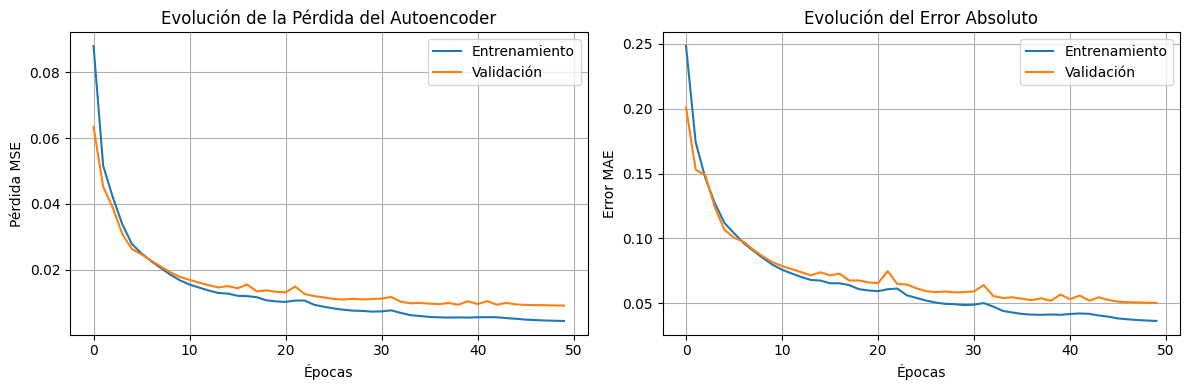

 Métricas finales del autoencoder:
   - Pérdida MSE: 0.0091
   - Error MAE: 0.0504


In [11]:
# Generar gráficas del progreso de entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_ae.history['loss'], label='Entrenamiento')
plt.plot(history_ae.history['val_loss'], label='Validación')
plt.title('Evolución de la Pérdida del Autoencoder')
plt.xlabel('Épocas')
plt.ylabel('Pérdida MSE')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_ae.history['mae'], label='Entrenamiento')
plt.plot(history_ae.history['val_mae'], label='Validación')
plt.title('Evolución del Error Absoluto')
plt.xlabel('Épocas')
plt.ylabel('Error MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Medir rendimiento final del autoencoder
test_loss, test_mae = autoencoder.evaluate(X_test_ae, X_test_ae, verbose=0)
print(f" Métricas finales del autoencoder:")
print(f"   - Pérdida MSE: {test_loss:.4f}")
print(f"   - Error MAE: {test_mae:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step


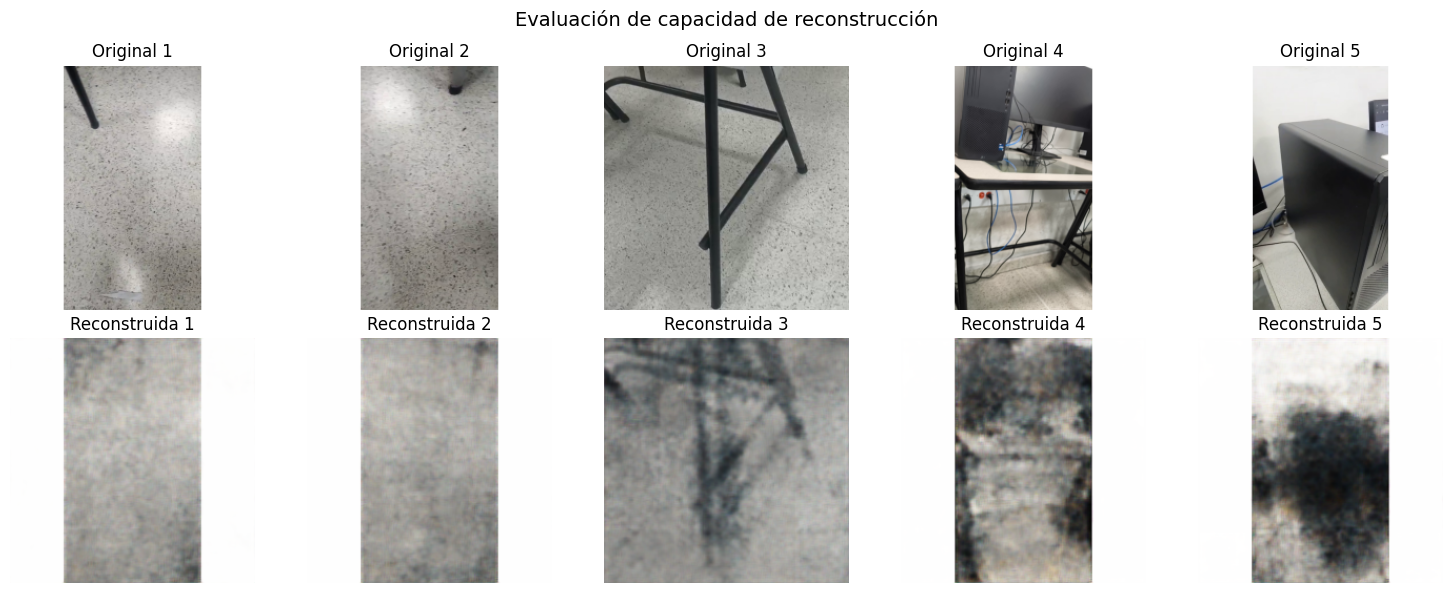

In [12]:
# Demostrar capacidad de reconstrucción del autoencoder
n_examples = 5
test_indices = np.random.choice(len(X_test_ae), n_examples, replace=False)

# Aplicar proceso de reconstrucción
reconstructed = autoencoder.predict(X_test_ae[test_indices])

plt.figure(figsize=(15, 6))
for i in range(n_examples):
    # Muestra original
    plt.subplot(2, n_examples, i + 1)
    plt.imshow(X_test_ae[test_indices[i]])
    plt.title(f'Original {i+1}')
    plt.axis('off')
    
    # Versión reconstruida
    plt.subplot(2, n_examples, i + 1 + n_examples)
    plt.imshow(reconstructed[i])
    plt.title(f'Reconstruida {i+1}')
    plt.axis('off')

plt.suptitle('Evaluación de capacidad de reconstrucción', fontsize=14)
plt.tight_layout()
plt.show()

##  Construcción del Clasificador
### Usando features del Encoder

In [13]:
# Obtener representaciones comprimidas mediante el codificador del autoencoder
print(" Generando características comprimidas...")

# Procesar en lotes para evitar problemas de memoria
batch_size = 32  # Procesar 32 imágenes a la vez
X_features_list = []

print(f" Procesando {X.shape[0]} imágenes en lotes de {batch_size}...")

for i in range(0, X.shape[0], batch_size):
    batch_end = min(i + batch_size, X.shape[0])
    batch = X[i:batch_end]
    
    # Procesar lote actual
    batch_features = autoencoder.encode(batch).numpy()
    X_features_list.append(batch_features)
    
    print(f" Lote {i//batch_size + 1}/{math.ceil(X.shape[0]/batch_size)} procesado ({batch_end}/{X.shape[0]} imágenes)")

# Concatenar todos los features
X_features = np.concatenate(X_features_list, axis=0)

print(f"\n Características obtenidas:")
print(f"   - Dimensiones originales: {X.shape}")
print(f"   - Dimensiones comprimidas: {X_features.shape}")
print(f"   - Compresión dimensional: {X.shape[1]*X.shape[2]*X.shape[3]} -> {X_features.shape[1]}")
print(f"   - Ratio de compresión: {(X.shape[1]*X.shape[2]*X.shape[3]) / X_features.shape[1]:.1f}x")

# Organizar datos para la tarea de clasificación
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

# Transformar etiquetas a formato categórico (codificación one-hot)
y_train_cat = keras.utils.to_categorical(y_train_clf, NUM_CLASSES)
y_test_cat = keras.utils.to_categorical(y_test_clf, NUM_CLASSES)

print(f"\n Partición para clasificación:")
print(f"   - Muestras de entrenamiento: {X_train_clf.shape[0]}")
print(f"   - Muestras de evaluación: {X_test_clf.shape[0]}")
print(f"   - Dimensionalidad de características: {X_train_clf.shape[1:]}")
print(f"   - Número de categorías: {NUM_CLASSES}")

 Generando características comprimidas...
 Procesando 1553 imágenes en lotes de 32...
 Lote 1/49 procesado (32/1553 imágenes)
 Lote 2/49 procesado (64/1553 imágenes)
 Lote 3/49 procesado (96/1553 imágenes)
 Lote 4/49 procesado (128/1553 imágenes)
 Lote 5/49 procesado (160/1553 imágenes)
 Lote 6/49 procesado (192/1553 imágenes)
 Lote 7/49 procesado (224/1553 imágenes)
 Lote 8/49 procesado (256/1553 imágenes)
 Lote 9/49 procesado (288/1553 imágenes)
 Lote 10/49 procesado (320/1553 imágenes)
 Lote 11/49 procesado (352/1553 imágenes)
 Lote 12/49 procesado (384/1553 imágenes)
 Lote 13/49 procesado (416/1553 imágenes)
 Lote 14/49 procesado (448/1553 imágenes)
 Lote 15/49 procesado (480/1553 imágenes)
 Lote 16/49 procesado (512/1553 imágenes)
 Lote 17/49 procesado (544/1553 imágenes)
 Lote 18/49 procesado (576/1553 imágenes)
 Lote 19/49 procesado (608/1553 imágenes)
 Lote 20/49 procesado (640/1553 imágenes)
 Lote 21/49 procesado (672/1553 imágenes)
 Lote 22/49 procesado (704/1553 imágenes)
 L

In [14]:
def crear_clasificador(input_dim, num_classes):
    """
    Arquitectura de red neuronal que procesa características del codificador
    para realizar predicción de categorías
    """
    inputs = keras.Input(shape=(input_dim,), name='classifier_input')
    
    # Capas densas con regularización para clasificación
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dropout(0.5)(x)
    
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    # Capa final con activación softmax para predicción multiclase
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)
    
    classifier = keras.Model(inputs, outputs, name='classifier')
    return classifier

# Instanciar y configurar el clasificador
classifier = crear_clasificador(LATENT_DIM, NUM_CLASSES)

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(" Clasificador implementado")
print(" Estructura del clasificador:")
classifier.summary()

 Clasificador implementado
 Estructura del clasificador:


Model: "classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ classifier_input (InputLayer)   │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,247 (227.53 KB)

 Trainable params: 58,247 (227.53 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del Clasificador

In [15]:
# Buscar modelo clasificador previamente entrenado
classifier_path = f"models/{CODIGO}_classifier.h5"

if os.path.exists(classifier_path):
    print(f" Restaurando clasificador desde: {classifier_path}")
    classifier = keras.models.load_model(classifier_path)
    print(" Clasificador restaurado correctamente!")
    
    # Medir rendimiento del modelo restaurado
    test_loss_clf, test_acc_clf = classifier.evaluate(X_test_clf, y_test_cat, verbose=0)
    print(f" Métricas del clasificador restaurado:")
    print(f"   - Precisión: {test_acc_clf:.4f} ({test_acc_clf*100:.2f}%)")
    print(f"   - Pérdida: {test_loss_clf:.4f}")
    
    # Generar historial simulado para mantener compatibilidad
    history_clf = type('History', (), {
        'history': {
            'accuracy': [test_acc_clf],
            'val_accuracy': [test_acc_clf],
            'loss': [test_loss_clf],
            'val_loss': [test_loss_clf]
        }
    })()
    
else:
    print(f" Modelo no localizado en: {classifier_path}")
    print(" Comenzando entrenamiento desde estado inicial...")
    
    # Configurar mecanismos de control del entrenamiento
    callbacks_clf = [
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            mode='max'
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=8,
            min_lr=1e-7
        )
    ]

    # Ejecutar optimización del clasificador
    print("\n Iniciando optimización del clasificador...")
    history_clf = classifier.fit(
        X_train_clf, y_train_cat,
        validation_data=(X_test_clf, y_test_cat),
        epochs=100,
        batch_size=8,
        callbacks=callbacks_clf,
        verbose=1
    )

    print(" Optimización del clasificador finalizada!")
    
    # Persistir modelo optimizado
    os.makedirs("models", exist_ok=True)
    classifier.save(classifier_path)
    print(f" Clasificador almacenado en: {classifier_path}")

 Modelo no localizado en: models/20251595004_classifier.h5
 Comenzando entrenamiento desde estado inicial...

 Iniciando optimización del clasificador...
Epoch 1/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2391 - loss: 3.8918 - val_accuracy: 0.5338 - val_loss: 1.4808 - learning_rate: 0.0010
Epoch 2/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3599 - loss: 1.8901 - val_accuracy: 0.6656 - val_loss: 1.2853 - learning_rate: 0.0010
Epoch 3/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4758 - loss: 1.4688 - val_accuracy: 0.7781 - val_loss: 0.9642 - learning_rate: 0.0010
Epoch 4/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5612 - loss: 1.2057 - val_accuracy: 0.8264 - val_loss: 0.7603 - learning_rate: 0.0010
Epoch 5/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6449 - loss: 1.0559 - val_accuracy: 0.8392 - val_loss: 0.6542 - learning_rate: 0.0010
Epoch 6/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6787 - loss: 0

 Optimización del clasificador finalizada!
 Clasificador almacenado en: models/20251595004_classifier.h5


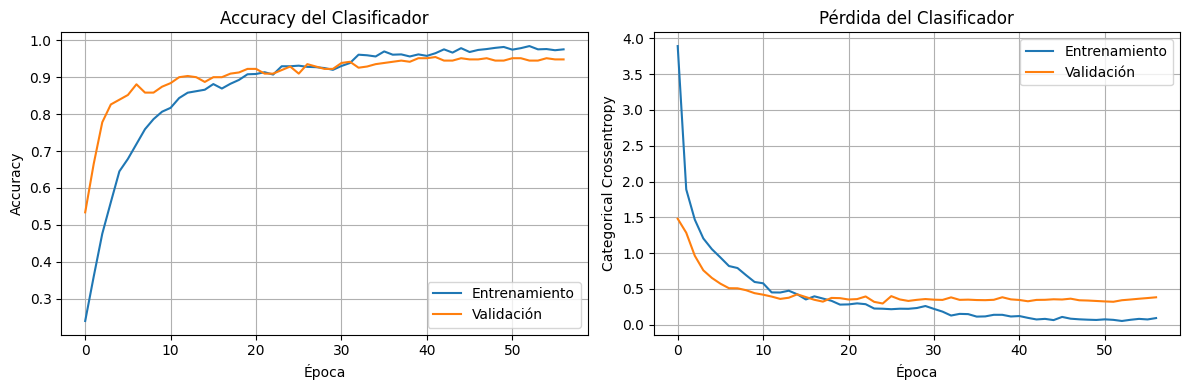

 Rendimiento del clasificador en test:
   - Accuracy: 0.9550 (95.50%)
   - Loss: 0.3281


In [16]:
# Visualizar progreso del entrenamiento del clasificador
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_clf.history['accuracy'], label='Entrenamiento')
plt.plot(history_clf.history['val_accuracy'], label='Validación')
plt.title('Accuracy del Clasificador')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_clf.history['loss'], label='Entrenamiento')
plt.plot(history_clf.history['val_loss'], label='Validación')
plt.title('Pérdida del Clasificador')
plt.xlabel('Época')
plt.ylabel('Categorical Crossentropy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Evaluar clasificador
test_loss_clf, test_acc_clf = classifier.evaluate(X_test_clf, y_test_cat, verbose=0)
print(f" Rendimiento del clasificador en test:")
print(f"   - Accuracy: {test_acc_clf:.4f} ({test_acc_clf*100:.2f}%)")
print(f"   - Loss: {test_loss_clf:.4f}")

## Evaluación y Análisis de Resultados

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


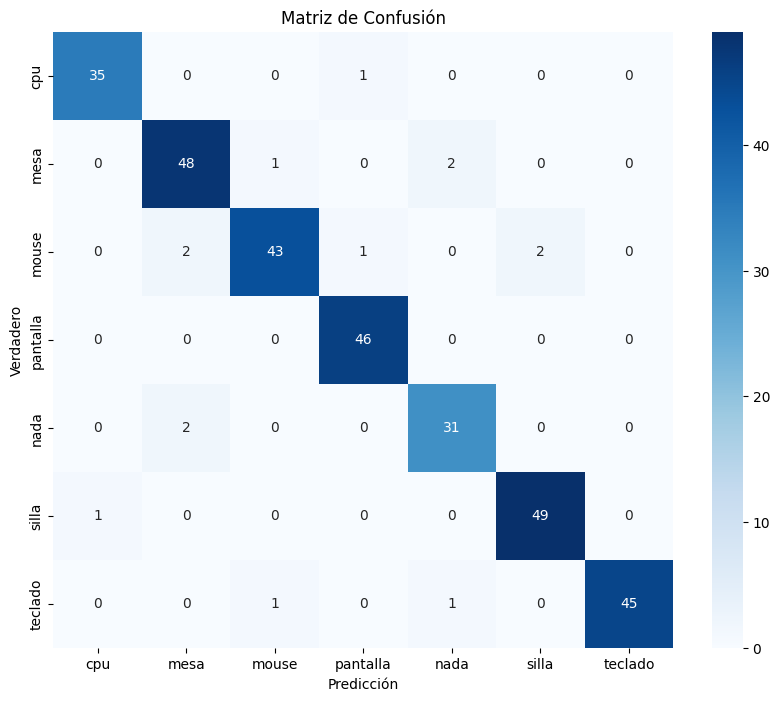

 Reporte de clasificación:
              precision    recall  f1-score   support

         cpu       0.97      0.97      0.97        36
        mesa       0.92      0.94      0.93        51
       mouse       0.96      0.90      0.92        48
    pantalla       0.96      1.00      0.98        46
        nada       0.91      0.94      0.93        33
       silla       0.96      0.98      0.97        50
     teclado       1.00      0.96      0.98        47

    accuracy                           0.95       311
   macro avg       0.95      0.96      0.95       311
weighted avg       0.96      0.95      0.95       311


 Accuracy por clase:
          cpu: 0.972 (97.2%)
         mesa: 0.941 (94.1%)
        mouse: 0.896 (89.6%)
     pantalla: 1.000 (100.0%)
         nada: 0.939 (93.9%)
        silla: 0.980 (98.0%)
      teclado: 0.957 (95.7%)


In [17]:
# Hacer predicciones
y_pred_proba = classifier.predict(X_test_clf)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=OBJETOS, yticklabels=OBJETOS)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.show()

# Reporte de clasificación
print(" Reporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=OBJETOS))

# Accuracy por clase
print("\n Accuracy por clase:")
for i, objeto in enumerate(OBJETOS):
    mask = y_true == i
    if np.sum(mask) > 0:
        acc_clase = np.mean(y_pred[mask] == y_true[mask])
        print(f"   {objeto:>10}: {acc_clase:.3f} ({acc_clase*100:.1f}%)")

Seleccionando muestras aleatorias por clase:
          cpu: muestra #123 seleccionada
         mesa: muestra #304 seleccionada
        mouse: muestra #63 seleccionada
     pantalla: muestra #120 seleccionada
         nada: muestra #61 seleccionada
        silla: muestra #24 seleccionada
      teclado: muestra #226 seleccionada
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

Mostrando predicciones para 7 muestras aleatorias:


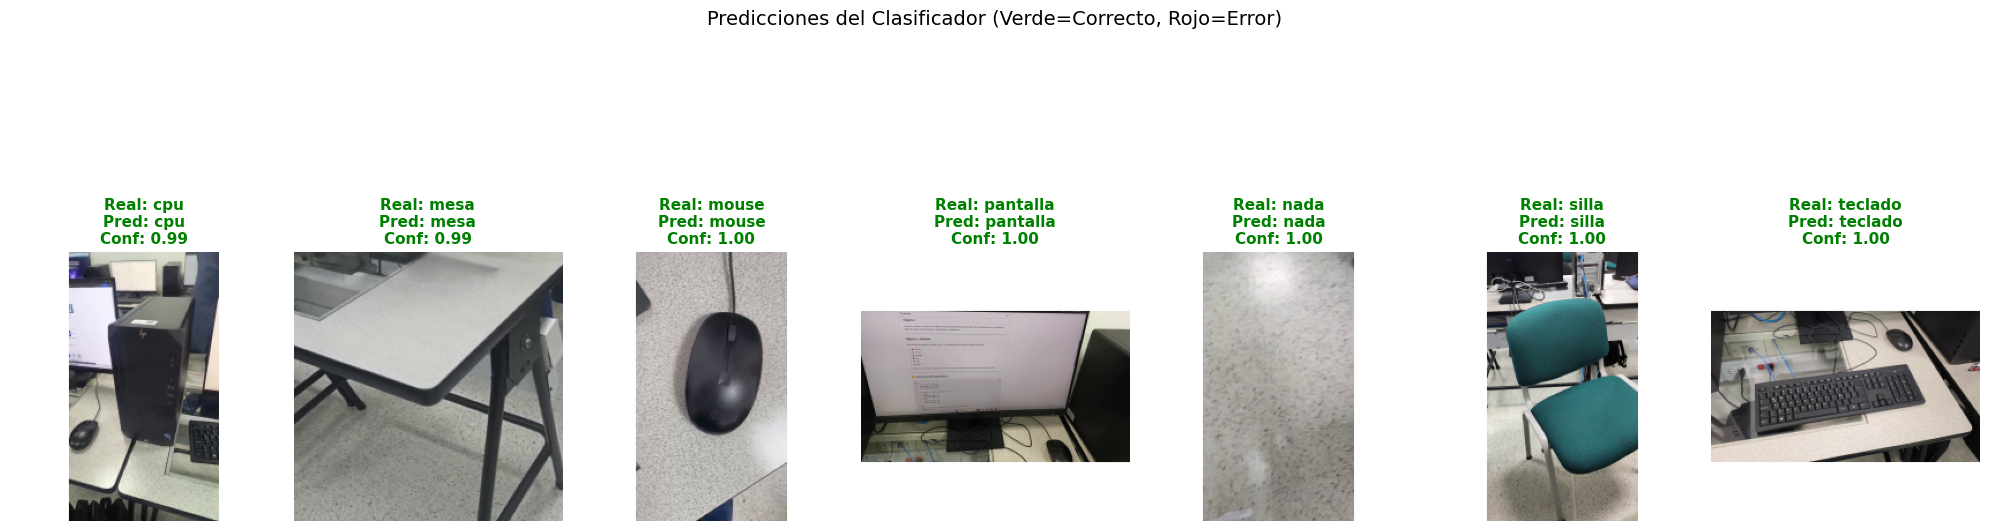


Resultados detallados por clase:

       CPU -> CORRECTO
             Muestra del test set: #123
             Top 3 predicciones:
             *        cpu: 0.989 (98.9%)
                 pantalla: 0.006 (0.6%)
                    mouse: 0.004 (0.4%)

      MESA -> CORRECTO
             Muestra del test set: #304
             Top 3 predicciones:
             *       mesa: 0.992 (99.2%)
                     nada: 0.007 (0.7%)
                 pantalla: 0.000 (0.0%)

     MOUSE -> CORRECTO
             Muestra del test set: #63
             Top 3 predicciones:
             *      mouse: 0.999 (99.9%)
                      cpu: 0.000 (0.0%)
                    silla: 0.000 (0.0%)

  PANTALLA -> CORRECTO
             Muestra del test set: #120
             Top 3 predicciones:
             *   pantalla: 1.000 (100.0%)
                     nada: 0.000 (0.0%)
                  teclado: 0.000 (0.0%)

      NADA -> CORRECTO
             Muestra del test set: #61
             Top 3 predicciones

In [18]:
plt.figure(figsize=(20, 8))

# Obtener división de datos originales (para imágenes)
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Seleccionar una muestra aleatoria de cada clase del conjunto de prueba
selected_indices = []
selected_labels = []

print("Seleccionando muestras aleatorias por clase:")

for clase in range(NUM_CLASSES):
    # Encontrar imágenes de esta clase en el conjunto de prueba
    indices_clase_clf = np.where(y_test_clf == clase)[0]
    
    if len(indices_clase_clf) > 0:
        # Seleccionar aleatoriamente una imagen de esta clase
        idx_seleccionado = np.random.choice(indices_clase_clf)
        selected_indices.append(idx_seleccionado)
        selected_labels.append(clase)
        
        print(f"   {OBJETOS[clase]:>10}: muestra #{idx_seleccionado} seleccionada")
    else:
        print(f"   No hay imágenes de la clase {OBJETOS[clase]} en el conjunto de prueba")

# Hacer predicciones para las muestras seleccionadas
if selected_indices:
    selected_features = X_test_clf[selected_indices]
    selected_images = X_test_orig[selected_indices]  # Imágenes originales correspondientes
    predictions = classifier.predict(selected_features)
    
    n_examples = len(selected_indices)
    print(f"\nMostrando predicciones para {n_examples} muestras aleatorias:")
    
    # Mostrar cada predicción
    for i in range(n_examples):
        plt.subplot(1, n_examples, i + 1)
        
        # Obtener predicción y confianza
        pred_proba = predictions[i]
        pred_class = np.argmax(pred_proba)
        true_class = selected_labels[i]
        confidence = pred_proba[pred_class]
        
        # Mostrar imagen original
        plt.imshow(selected_images[i])
        
        # Color del título según acierto
        color = 'green' if pred_class == true_class else 'red'
        
        plt.title(f'Real: {OBJETOS[true_class]}\n'
                  f'Pred: {OBJETOS[pred_class]}\n'
                  f'Conf: {confidence:.2f}', 
                  color=color, fontsize=11, weight='bold')
        plt.axis('off')

plt.suptitle('Predicciones del Clasificador (Verde=Correcto, Rojo=Error)', 
             fontsize=14, y=0.95)
plt.tight_layout()
plt.show()

# Mostrar estadísticas detalladas de las predicciones
print("\nResultados detallados por clase:")
print("=" * 70)

for i, idx in enumerate(selected_indices):
    true_class = selected_labels[i]
    pred_proba = predictions[i]
    pred_class = np.argmax(pred_proba)
    confidence = pred_proba[pred_class]
    
    # Mostrar las 3 predicciones más probables
    top3_indices = np.argsort(pred_proba)[::-1][:3]
    
    status = "CORRECTO" if pred_class == true_class else "ERROR"
    
    print(f"\n{OBJETOS[true_class].upper():>10} -> {status}")
    print(f"{'':>12} Muestra del test set: #{idx}")
    print(f"{'':>12} Top 3 predicciones:")
    for j, top_idx in enumerate(top3_indices):
        prob = pred_proba[top_idx]
        marker = "*" if j == 0 else " "
        print(f"{'':>12} {marker} {OBJETOS[top_idx]:>10}: {prob:.3f} ({prob*100:.1f}%)")

print("\n" + "=" * 70)

# Estadísticas generales del conjunto de prueba
y_pred_all = classifier.predict(X_test_clf)
y_pred_classes = np.argmax(y_pred_all, axis=1)

print(f"\nESTADISTICAS GENERALES DEL CONJUNTO DE PRUEBA:")
print(f"   - Total muestras evaluadas: {len(X_test_clf)}")
print(f"   - Accuracy general: {np.mean(y_pred_classes == y_test_clf):.3f}")

# Accuracy por clase en todo el conjunto de prueba
print(f"\nAccuracy por clase (conjunto completo):")
for clase in range(NUM_CLASSES):
    mask = y_test_clf == clase
    if np.sum(mask) > 0:
        acc_clase = np.mean(y_pred_classes[mask] == y_test_clf[mask])
        total_clase = np.sum(mask)
        print(f"   {OBJETOS[clase]:>10}: {acc_clase:.3f} ({acc_clase*100:.1f}%) - {total_clase} muestras")
    else:
        print(f"   {OBJETOS[clase]:>10}: No hay muestras en test")

print("\nEvaluacion completada mostrando imagenes originales")

In [19]:
def evaluar_modelo_con_video(video_path, autoencoder, classifier, objetos, img_size=(233, 233), max_frames=20):
    """
    Evalúa el modelo entrenado con un video de la carpeta raw
    Extrae frames, los procesa y muestra predicciones
    """
    
    def resize_con_padding(imagen, target_size):
        """Aplicar el mismo preprocessing que en entrenamiento"""
        h, w = imagen.shape[:2]
        target_w, target_h = target_size
        
        # Calcular factor de escala
        scale_w = target_w / w
        scale_h = target_h / h
        scale = min(scale_w, scale_h)
        
        # Redimensionar manteniendo relación de aspecto
        new_w = int(w * scale)
        new_h = int(h * scale)
        resized = cv2.resize(imagen, (new_w, new_h), interpolation=cv2.INTER_AREA)
        
        # Crear imagen con fondo blanco
        resultado = np.ones((target_h, target_w, 3), dtype=imagen.dtype) * 255
        
        # Centrar la imagen
        start_x = (target_w - new_w) // 2
        start_y = (target_h - new_h) // 2
        end_x = start_x + new_w
        end_y = start_y + new_h
        
        resultado[start_y:end_y, start_x:end_x] = resized
        return resultado
    
    print(f"Evaluando modelo con video: {video_path}")
    
    # Verificar si el video existe
    if not os.path.exists(video_path):
        print(f"Error: Video no encontrado en {video_path}")
        return
    
    # Abrir video
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: No se pudo abrir el video {video_path}")
        return
    
    # Obtener información del video
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps if fps > 0 else 0
    
    print(f"Información del video:")
    print(f"   - FPS: {fps:.2f}")
    print(f"   - Total frames: {total_frames}")
    print(f"   - Duración: {duration:.2f} segundos")
    print(f"   - Extrayendo {max_frames} frames para evaluación")
    
    # Calcular intervalo de frames
    if total_frames <= max_frames:
        frame_interval = 1
        max_frames = total_frames
    else:
        frame_interval = total_frames // max_frames
    
    # Extraer y procesar frames
    frames_procesados = []
    frames_originales = []
    frame_count = 0
    extracted_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret or extracted_count >= max_frames:
            break
            
        if frame_count % frame_interval == 0:
            # Convertir BGR a RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames_originales.append(frame_rgb.copy())
            
            # Aplicar preprocessing
            frame_processed = resize_con_padding(frame_rgb, img_size)
            frame_normalized = frame_processed.astype(np.float32) / 255.0
            frames_procesados.append(frame_normalized)
            
            extracted_count += 1
            
        frame_count += 1
    
    cap.release()
    
    # Convertir a arrays numpy
    frames_array = np.array(frames_procesados)
    print(f"\nFrames extraídos y procesados: {len(frames_array)}")
    print(f"Forma de frames procesados: {frames_array.shape}")
    
    # Extraer features con el encoder
    print("Extrayendo features con el encoder...")
    features = autoencoder.encode(frames_array).numpy()
    
    # Hacer predicciones
    print("Realizando predicciones...")
    predictions = classifier.predict(features)
    predicted_classes = np.argmax(predictions, axis=1)
    confidences = np.max(predictions, axis=1)
    
    # Mostrar resultados
    print(f"\nResultados de la evaluación:")
    print("=" * 60)
    
    # Contar predicciones por clase
    unique_preds, counts = np.unique(predicted_classes, return_counts=True)
    
    print(f"Distribución de predicciones:")
    for clase, count in zip(unique_preds, counts):
        porcentaje = (count / len(predicted_classes)) * 100
        print(f"   {objetos[clase]:>10}: {count:>2} frames ({porcentaje:>5.1f}%)")
    
    # Predicción más frecuente
    clase_mas_frecuente = unique_preds[np.argmax(counts)]
    confianza_promedio = np.mean(confidences[predicted_classes == clase_mas_frecuente])
    
    print(f"\nPredicción final del video:")
    print(f"   Clase predominante: {objetos[clase_mas_frecuente]}")
    print(f"   Confianza promedio: {confianza_promedio:.3f}")
    
    # Visualizar algunos frames con predicciones
    n_ejemplos = min(8, len(frames_originales))
    plt.figure(figsize=(20, 8))
    
    for i in range(n_ejemplos):
        plt.subplot(2, n_ejemplos // 2, i + 1)
        plt.imshow(frames_originales[i])
        
        pred_class = predicted_classes[i]
        confidence = confidences[i]
        
        color = 'green' if confidence > 0.7 else 'orange' if confidence > 0.5 else 'red'
        
        # Destacar si es la clase predominante
        predominante_marker = " ★" if pred_class == clase_mas_frecuente else ""
        
        plt.title(f'Frame {i+1}\n{objetos[pred_class]}{predominante_marker}\nConf: {confidence:.3f}', 
                 color=color, fontsize=10, weight='bold')
        plt.axis('off')
    
    # Título principal con información de la clase predominante
    main_title = f'Evaluación del video: {os.path.basename(video_path)}\nClase Predominante: {objetos[clase_mas_frecuente]} (Confianza promedio: {confianza_promedio:.3f})'
    plt.suptitle(main_title, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
    return {
        'predicciones': predicted_classes,
        'confidencias': confidences,
        'clase_predominante': objetos[clase_mas_frecuente],
        'confianza_promedio': confianza_promedio,
        'distribucion': dict(zip([objetos[i] for i in unique_preds], counts))
    }

In [20]:
# Listar videos disponibles en la carpeta raw
print("Videos disponibles en la carpeta raw:")
videos_disponibles = glob.glob(os.path.join(RAW_PATH, "*.mp4"))

for i, video in enumerate(videos_disponibles):
    nombre_video = os.path.basename(video)
    print(f"   {i+1}. {nombre_video}")

Videos disponibles en la carpeta raw:
   1. 20172167090_cpu.mp4
   2. 20172167090_mesa.mp4
   3. 20172167090_mouse.mp4
   4. 20172167090_nada.mp4
   5. 20172167090_pantalla.mp4
   6. 20172167090_silla.mp4
   7. 20172167090_teclado.mp4
   8. 20241196002_cpu.mp4
   9. 20241196002_mesa.mp4
   10. 20241196002_mouse.mp4
   11. 20241196002_pantalla.mp4
   12. 20241196002_ruido.mp4
   13. 20241196002_silla.mp4
   14. 20241196002_teclado.mp4
   15. 20241695014_cpu.mp4
   16. 20241695014_mesa.mp4
   17. 20241695014_mouse.mp4
   18. 20241695014_pantalla.mp4
   19. 20241695014_silla.mp4
   20. 20241695014_teclado.mp4
   21. 20242595003_cpu.mp4
   22. 20242595003_mesa.mp4
   23. 20242595003_mouse.mp4
   24. 20242595003_pantalla.mp4
   25. 20242595003_silla.mp4
   26. 20242595003_teclado.mp4
   27. 20242595005_cpu.mp4
   28. 20242595005_mesa.mp4
   29. 20242595005_mouse.mp4
   30. 20242595005_pantalla.mp4
   31. 20242595005_ruido.mp4
   32. 20242595005_silla.mp4
   33. 20242595005_teclado.mp4
   34


Evaluando con: 20172167090_mouse.mp4
Evaluando modelo con video: raw\20172167090_mouse.mp4
Información del video:
   - FPS: 30.00
   - Total frames: 83
   - Duración: 2.77 segundos
   - Extrayendo 20 frames para evaluación

Frames extraídos y procesados: 20
Forma de frames procesados: (20, 233, 233, 3)
Extrayendo features con el encoder...
Realizando predicciones...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

Resultados de la evaluación:
Distribución de predicciones:
        mouse: 19 frames ( 95.0%)
     pantalla:  1 frames (  5.0%)

Predicción final del video:
   Clase predominante: mouse
   Confianza promedio: 0.954


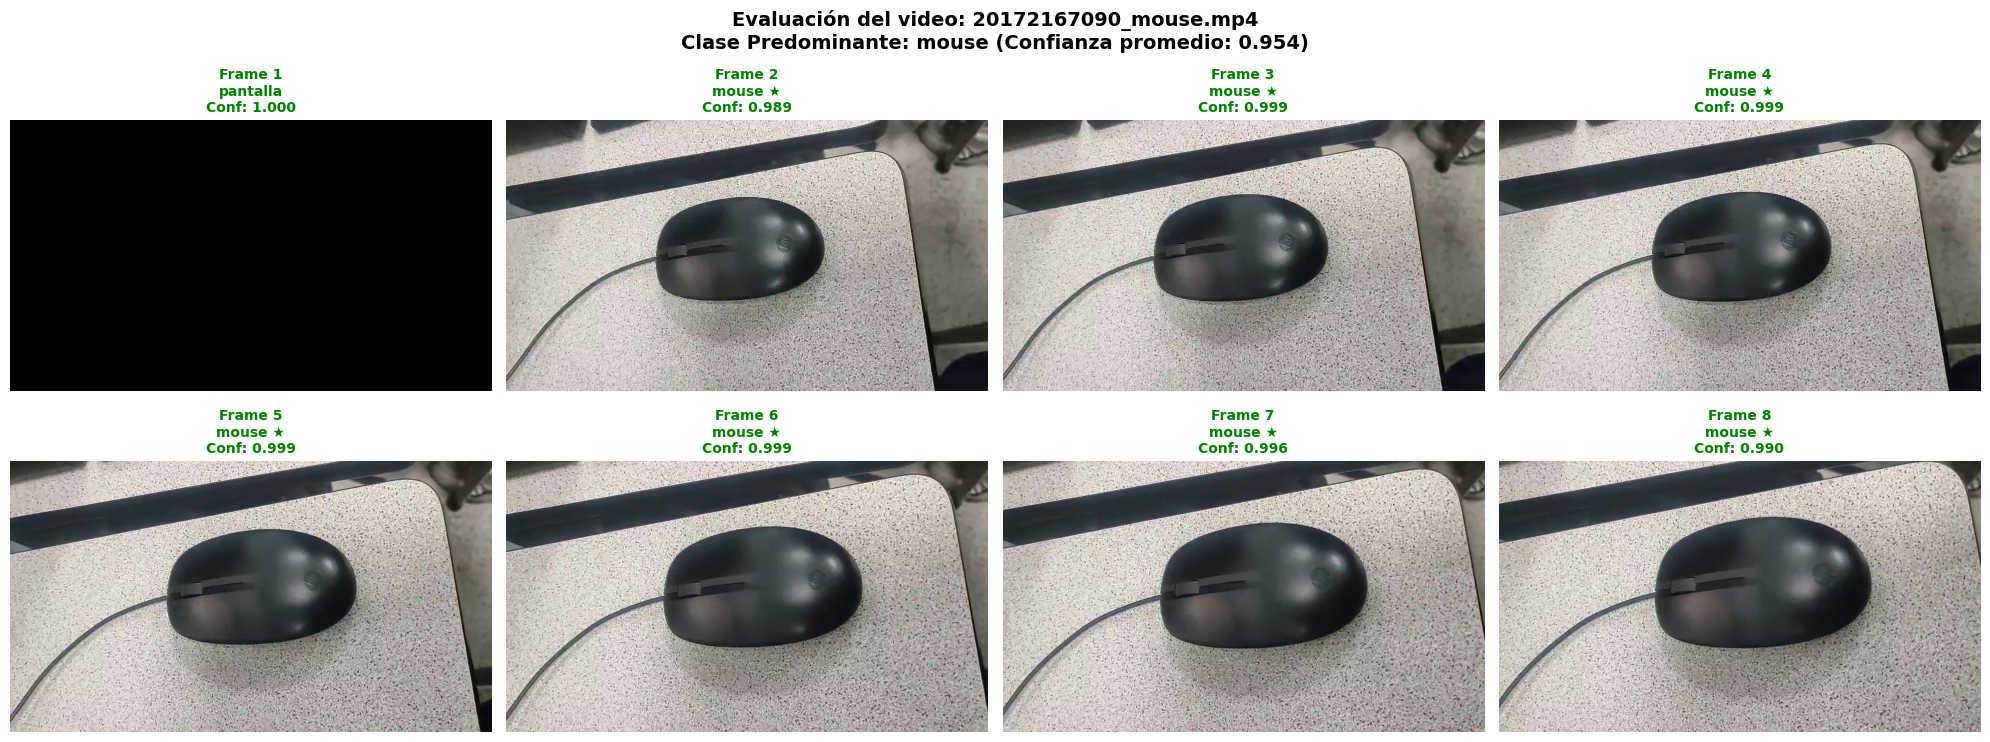

In [24]:
video = 3
cantidad_frames = 20

if videos_disponibles:
    
    # Evaluar con el primer video encontrado
    video_seleccionado = videos_disponibles[video - 1]  
    
    print(f"\nEvaluando con: {os.path.basename(video_seleccionado)}")
    print("=" * 60)
    
    # Realizar evaluación
    resultados = evaluar_modelo_con_video(
        video_seleccionado, 
        autoencoder, 
        classifier, 
        OBJETOS, 
        IMG_SIZE,
        max_frames=cantidad_frames  # Ajusta el número de frames a evaluar
    )
    
else:
    print("No se encontraron videos .mp4 en la carpeta raw")
    print(f"Verificar contenido de: {RAW_PATH}")

##  Guardar Modelos Entrenados

In [22]:
# Crear directorio models si no existe
models_dir = "models"
os.makedirs(models_dir, exist_ok=True)

autoencoder_path = os.path.join(models_dir, f"{CODIGO}_autoencoder.weights.h5")
classifier_path = os.path.join(models_dir, f"{CODIGO}_classifier.h5")

# Guardar modelos
autoencoder.save_weights(autoencoder_path)  # Usar save_weights para modelo personalizado
classifier.save(classifier_path)

print("Modelos guardados:")
print(f"   - Autoencoder weights: {autoencoder_path}")
print(f"   - Clasificador: {classifier_path}")


def cargar_autoencoder(weights_path, latent_dim, shape):
    """Función para recrear y cargar el autoencoder personalizado"""
    ae = Autoencoder(latent_dim, shape)
    # Construir el modelo con datos de ejemplo
    sample = tf.random.normal((1,) + shape)
    _ = ae(sample)
    # Cargar pesos
    ae.load_weights(weights_path)
    return ae

Modelos guardados:
   - Autoencoder weights: models\20251595004_autoencoder.weights.h5
   - Clasificador: models\20251595004_classifier.h5
